<h3>Use PCA to reduce the dimensionality of an image dataset and apply KNN for classification</h3>

In [16]:
import shutil
import os
import cv2
from sklearn.decomposition import PCA
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import matplotlib.pyplot as plt




In [2]:
train_csv = pd.read_csv("../datasets/butterflies/Training_set.csv")
test_csv = pd.read_csv("../datasets/butterflies/Testing_set.csv")

In [15]:
train_csv["label"].unique().shape

(75,)

In [5]:
train_csv["filename"]

0          Image_1.jpg
1          Image_2.jpg
2          Image_3.jpg
3          Image_4.jpg
4          Image_5.jpg
             ...      
6494    Image_6495.jpg
6495    Image_6496.jpg
6496    Image_6497.jpg
6497    Image_6498.jpg
6498    Image_6499.jpg
Name: filename, Length: 6499, dtype: object

In [12]:
images = []
for filename in train_csv["filename"]:
    image = cv2.imread(os.path.join("../datasets/butterflies/train", filename), cv2.IMREAD_GRAYSCALE)
    image = image.flatten()
    images.append(image)

images_df = pd.DataFrame(images)




In [18]:
images_df["label"] = train_csv["label"].values

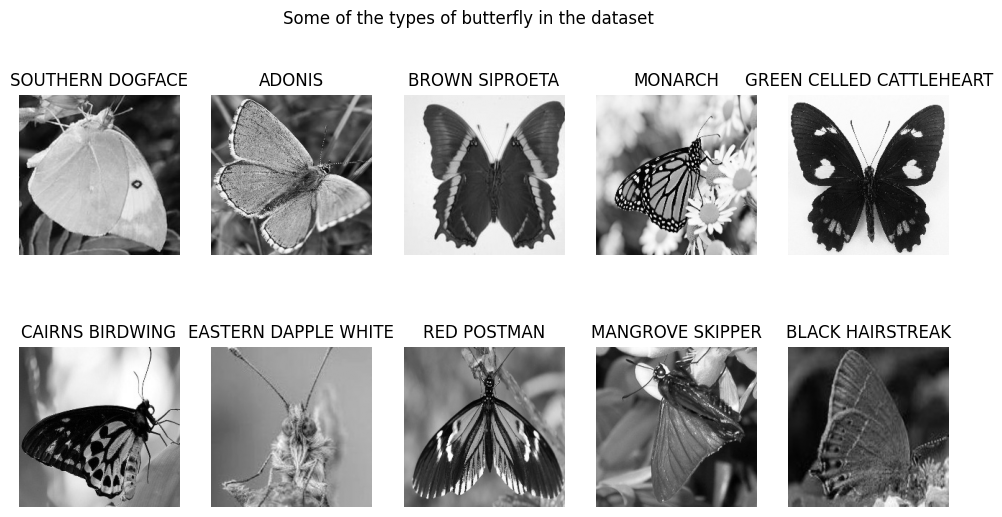

In [39]:
i=0
plt.subplots(2, 5, figsize=(12, 6))
plt.suptitle("Some of the types of butterfly in the dataset", fontsize=12)
for class_name in train_csv["label"].unique()[0:10]:
    image = train_csv[train_csv["label"] == class_name]["filename"].values[0]
    image = cv2.imread(os.path.join("../datasets/butterflies/train", image), cv2.IMREAD_GRAYSCALE)
    plt.subplot(2, 5, i+1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")
    i += 1


In [40]:
images_df

,0,1,2,3,4,5,6,7,8,9,...,50167,50168,50169,50170,50171,50172,50173,50174,50175,label
0,36,36,36,36,37,38,39,40,35,39,...,35,38,39,41,45,49,53,55,56,SOUTHERN DOGFACE
1,138,143,149,153,150,141,131,124,112,101,...,80,83,85,91,101,113,118,114,108,ADONIS
2,233,233,233,233,233,233,233,233,233,233,...,234,234,234,234,233,233,233,234,234,BROWN SIPROETA
3,228,231,234,236,237,237,237,236,237,237,...,178,189,200,212,220,227,230,229,228,MONARCH
4,251,251,251,251,251,252,251,251,251,251,...,246,243,245,245,245,246,248,248,247,GREEN CELLED CATTLEHEART
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6494,130,130,130,131,132,132,131,129,128,130,...,185,183,184,186,173,118,121,156,178,MANGROVE SKIPPER
6495,140,183,192,196,201,218,193,208,210,196,...,104,116,56,32,16,12,24,70,46,MOURNING CLOAK
6496,49,49,50,50,49,47,46,46,50,51,...,34,31,29,28,28,29,29,30,30,APPOLLO
6497,236,235,235,235,234,233,234,237,238,242,...,221,180,158,166,175,183,196,198,201,ELBOWED PIERROT


In [ ]:
pca = PCA(n_components=74)
images = images_df.drop(columns=["label"])
pca_images = pca.fit_transform(images)
pca_images_df = pd.DataFrame(pca_images)


Training a KNN classifier on the original images dataset

In [ ]:
knn_01 = 